In [15]:
import json

sample = ds[0]

gt = json.loads(sample["ground_truth"])

print(gt.keys())

dict_keys(['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare'])


In [16]:
import pprint
pprint.pprint(gt)

{'dontcare': [[{'x1': 41,
                'x2': 149,
                'x3': 151,
                'x4': 39,
                'y1': 635,
                'y2': 635,
                'y3': 649,
                'y4': 649}]],
 'gt_parse': {'menu': {'cnt': '2',
                       'itemsubtotal': '60.000',
                       'nm': '-TICKET CP',
                       'num': '901016',
                       'price': '60.000'},
              'sub_total': {'discount_price': '-60.000',
                            'subtotal_price': '60.000',
                            'tax_price': '5.455'},
              'total': {'creditcardprice': '60.000',
                        'menuqty_cnt': '2.00',
                        'total_price': '60.000'}},
 'meta': {'image_id': 0,
          'image_size': {'height': 648, 'width': 432},
          'split': 'test',
          'version': '2.0.0'},
 'repeating_symbol': [[{'quad': {'x1': 46,
                                 'x2': 346,
                                 

In [17]:
def print_gt_text(sample):
    gt = json.loads(sample["ground_truth"])
    
    for line in gt["valid_line"]:
        words = [w["text"] for w in line["words"]]
        print(" ".join(words))

print_gt_text(ds[0])

901016
-TICKET CP
2
60.000
60.000
TOTAL DISC $ -60.000
TAX 5.455
Subtotal 60.000
TOTAL 60.000
(Qty 2.00
EDC CIMB NIAGA No: xx7730 60.000


In [30]:
import json
import re
from pathlib import Path

import pandas as pd
from datasets import load_dataset
from rapidfuzz.distance import Levenshtein

In [31]:
OCR_FILES = {
    "paddle": Path("/root/lorex-ocr-llm-experiments/results/cord_ocr/paddle_ocr_cord_test_filtered.json"),
    "tesseract": Path("/root/lorex-ocr-llm-experiments/results/cord_ocr/tesseract_ocr_cord_test_filtered.json"),
    "easyocr": Path("/root/lorex-ocr-llm-experiments/results/cord_ocr/easyocr_ocr_cord_test_filtered.json"),
    "doctr": Path("/root/lorex-ocr-llm-experiments/results/cord_ocr/doctr_ocr_cord_test_filtered.json"),
    "openocr": Path("/root/lorex-ocr-llm-experiments/results/cord_ocr/openocr_ocr_cord_test_filtered.json"),
}

In [32]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

ocr_data = {name: load_json(path) for name, path in OCR_FILES.items() if path.exists()}
{k: len(v) for k, v in ocr_data.items()}

{'paddle': 83, 'tesseract': 83, 'easyocr': 83, 'doctr': 83, 'openocr': 83}

In [33]:
def image_id(name):
    return Path(str(name)).stem

In [34]:
id_sets = []
for name, records in ocr_data.items():
    ids = {image_id(r["source_image"]) for r in records}
    id_sets.append(ids)

common_ids = sorted(set.intersection(*id_sets), key=int)

print("Common filtered IDs:", len(common_ids))
print(common_ids[:10])

Common filtered IDs: 83
['0', '1', '2', '3', '4', '6', '7', '8', '9', '10']


In [35]:
ds = load_dataset("naver-clova-ix/cord-v2", split="test")
print("CORD test size:", len(ds))

CORD test size: 100


In [36]:
def build_gt_text(sample):
    gt = json.loads(sample["ground_truth"])
    valid_line = gt.get("valid_line", [])

    rows = []

    for line in valid_line:
        words = line.get("words", [])
        clean_words = []

        for w in words:
            txt = str(w.get("text", "")).strip()
            if not txt:
                continue

            quad = w.get("quad", {})
            x1 = quad.get("x1", 0)
            row_id = w.get("row_id", 0)

            clean_words.append({
                "text": txt,
                "x1": x1,
                "row_id": row_id,
            })

        if clean_words:
            # sort words left to right
            clean_words = sorted(clean_words, key=lambda z: z["x1"])
            line_text = " ".join(w["text"] for w in clean_words)
            # use row_id of first word for stable vertical ordering
            rows.append((clean_words[0]["row_id"], line_text))

    # sort lines top-to-bottom by row_id
    rows = sorted(rows, key=lambda z: z[0])

    return "\n".join(line_text for _, line_text in rows)

In [37]:
gt_text_by_id = {}
for i, sample in enumerate(ds):
    gt_text_by_id[str(i)] = build_gt_text(sample)

print(gt_text_by_id["0"])

901016
-TICKET CP
2
60.000
60.000
TOTAL DISC $ -60.000
TAX 5.455
Subtotal 60.000
TOTAL 60.000
(Qty 2.00
EDC CIMB NIAGA No: xx7730 60.000


In [38]:
sid = "0"
print("GT:\n", gt_text_by_id[sid], "\n")

for ocr_name, records in ocr_data.items():
    rec_map = {image_id(r["source_image"]): r for r in records}
    print(f"--- {ocr_name.upper()} ---")
    print(rec_map[sid]["ocr_text"])
    print()

GT:
 901016
-TICKET CP
2
60.000
60.000
TOTAL DISC $ -60.000
TAX 5.455
Subtotal 60.000
TOTAL 60.000
(Qty 2.00
EDC CIMB NIAGA No: xx7730 60.000 

--- PADDLE ---
901016
-TICKET CP
2
60,000
00,000
TOTAL DISC $
-60,000
TAX
5.455
Subtotal
60.000
TOTAL
(Qty2.0060.000
-EDC CIMB NIAGA NO: XX7730
60.000

--- TESSERACT ---
-TICKET CP
2 60,000 £0,000
901016
TOTAL DISC $
TAX
Subtotal
TOTAL caty 2.00 60,000
= EDC CINB NIAGA No: xx7730 60.000
ee maeh Tur),

--- EASYOCR ---
901016
-TICKET Cp
60,0oo
EO,Q00
TOTAL dis:
60,000
tak
5,455
Subtota]
6O,000
ToTaL
(Oty
00
60
000
EdC CIMB NIAGA No: xx7730
60,000

--- DOCTR ---
-
901016
TICKET CP
2
60,000
C0.000
TOTAL DISC $
-60.000
TAX
5.455
Subtotal
G0.000
TOTAL
(Qty
2.00
60.000
-
- EDC CIMB NIAGA No: XX7730
60.000
CICTONER THEA

--- OPENOCR ---
···
901016
-TICKEI CP
2
一
60.000
80.000
TOTAL DISC S
-60.000
TAX
5.455
Subtotal
60.000
TOTAL
(Qty2.00 60.000
EDC CIMB NIAGA No: XX7730
60.000



In [39]:
def normalize_strict(text):
    if text is None:
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_light(text):
    if text is None:
        return ""

    text = str(text).lower()

    # only very light cleanup
    text = text.replace(",", ".")
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [40]:
def cer(pred, gold, normalize_fn):
    pred = normalize_fn(pred)
    gold = normalize_fn(gold)

    if len(gold) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return Levenshtein.distance(pred, gold) / len(gold)

def wer(pred, gold, normalize_fn):
    pred_words = normalize_fn(pred).split()
    gold_words = normalize_fn(gold).split()

    if len(gold_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return Levenshtein.distance(pred_words, gold_words) / len(gold_words)

In [41]:
sid = "0"

for ocr_name, records in ocr_data.items():
    rec_map = {image_id(r["source_image"]): r for r in records}
    pred = rec_map[sid]["ocr_text"]
    gold = gt_text_by_id[sid]

    print("OCR:", ocr_name)
    print("CER strict:", cer(pred, gold, normalize_strict))
    print("CER light :", cer(pred, gold, normalize_light))
    print("WER strict:", wer(pred, gold, normalize_strict))
    print("WER light :", wer(pred, gold, normalize_light))
    print("-" * 40)

OCR: paddle
CER strict: 0.16176470588235295
CER light : 0.11764705882352941
WER strict: 0.375
WER light : 0.20833333333333334
----------------------------------------
OCR: tesseract
CER strict: 0.5073529411764706
CER light : 0.4852941176470588
WER strict: 0.625
WER light : 0.5833333333333334
----------------------------------------
OCR: easyocr
CER strict: 0.29411764705882354
CER light : 0.18382352941176472
WER strict: 0.7083333333333334
WER light : 0.5416666666666666
----------------------------------------
OCR: doctr
CER strict: 0.2867647058823529
CER light : 0.2647058823529412
WER strict: 0.5
WER light : 0.4166666666666667
----------------------------------------
OCR: openocr
CER strict: 0.17647058823529413
CER light : 0.16176470588235295
WER strict: 0.375
WER light : 0.3333333333333333
----------------------------------------


In [43]:
rows = []

for ocr_name, records in ocr_data.items():
    rec_map = {image_id(r["source_image"]): r for r in records}

    for sid in common_ids:
        pred = rec_map[sid].get("ocr_text", "")
        gold = gt_text_by_id.get(sid, "")

        rows.append({
            "ocr": ocr_name,
            "source_image": f"{sid}.png",
            "cer_strict": cer(pred, gold, normalize_strict),
            "cer_light": cer(pred, gold, normalize_light),
            "wer_strict": wer(pred, gold, normalize_strict),
            "wer_light": wer(pred, gold, normalize_light),
        })

ocr_eval_df = pd.DataFrame(rows)
ocr_eval_df

,ocr,source_image,cer_strict,cer_light,wer_strict,wer_light
0,paddle,0.png,0.161765,0.117647,0.375000,0.208333
1,paddle,1.png,0.847222,0.847222,0.916667,0.916667
2,paddle,2.png,0.328125,0.328125,0.629630,0.629630
3,paddle,3.png,0.189873,0.189873,0.333333,0.333333
4,paddle,4.png,0.176871,0.176871,0.478261,0.478261
...,...,...,...,...,...,...
410,openocr,94.png,0.539394,0.539394,1.466667,1.466667
411,openocr,95.png,0.520000,0.504000,0.739130,0.739130
412,openocr,96.png,0.397959,0.397959,0.578947,0.578947
413,openocr,97.png,0.356436,0.356436,0.421053,0.421053


In [44]:
cer_strict_summary = (
    ocr_eval_df.groupby("ocr")["cer_strict"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

cer_light_summary = (
    ocr_eval_df.groupby("ocr")["cer_light"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

wer_strict_summary = (
    ocr_eval_df.groupby("ocr")["wer_strict"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

wer_light_summary = (
    ocr_eval_df.groupby("ocr")["wer_light"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

print("CER strict")
display(cer_strict_summary)

print("CER light")
display(cer_light_summary)

print("WER strict")
display(wer_strict_summary)

print("WER light")
display(wer_light_summary)

CER strict


,mean,median,std,count
ocr,,,,
doctr,0.183617,0.119403,0.201292,83
openocr,0.193548,0.170213,0.151758,83
easyocr,0.310744,0.267857,0.224284,83
paddle,0.323740,0.224719,0.355544,83
tesseract,0.672198,0.720000,0.303338,83


CER light


,mean,median,std,count
ocr,,,,
doctr,0.178912,0.116071,0.196382,83
openocr,0.187347,0.161765,0.150224,83
easyocr,0.285857,0.215517,0.217606,83
paddle,0.317949,0.219101,0.351028,83
tesseract,0.666569,0.720000,0.302892,83


WER strict


,mean,median,std,count
ocr,,,,
openocr,0.378834,0.375000,0.234694,83
doctr,0.381216,0.272727,0.404924,83
paddle,0.509804,0.388889,0.680345,83
easyocr,0.734266,0.692308,0.354766,83
tesseract,0.850213,0.923077,0.346218,83


WER light


,mean,median,std,count
ocr,,,,
openocr,0.350455,0.320000,0.219954,83
doctr,0.368061,0.259259,0.402916,83
paddle,0.493113,0.357143,0.684437,83
easyocr,0.689692,0.666667,0.351344,83
tesseract,0.847346,0.923077,0.347252,83


In [45]:
OUT_DIR = Path("/root/lorex-ocr-llm-experiments/results/cord_eval_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ocr_eval_df.to_csv(OUT_DIR / "ocr_eval_per_image.csv", index=False)

cer_strict_summary.to_csv(OUT_DIR / "cer_strict_summary.csv")
cer_light_summary.to_csv(OUT_DIR / "cer_light_summary.csv")

wer_strict_summary.to_csv(OUT_DIR / "wer_strict_summary.csv")
wer_light_summary.to_csv(OUT_DIR / "wer_light_summary.csv")

print("Saved all results to:", OUT_DIR)

Saved all results to: /root/lorex-ocr-llm-experiments/results/cord_eval_final


In [46]:
cer_plot = cer_light_summary.reset_index()[["ocr", "mean"]].copy()
cer_plot["metric"] = "CER"

wer_plot = wer_light_summary.reset_index()[["ocr", "mean"]].copy()
wer_plot["metric"] = "WER"

plot_df = pd.concat([cer_plot, wer_plot], ignore_index=True)
plot_df["mean_pct"] = plot_df["mean"] * 100

plot_df

,ocr,mean,metric,mean_pct
0,doctr,0.178912,CER,17.891236
1,openocr,0.187347,CER,18.734739
2,easyocr,0.285857,CER,28.585680
3,paddle,0.317949,CER,31.794931
4,tesseract,0.666569,CER,66.656913
5,openocr,0.350455,WER,35.045459
6,doctr,0.368061,WER,36.806127
7,paddle,0.493113,WER,49.311346
8,easyocr,0.689692,WER,68.969167
9,tesseract,0.847346,WER,84.734565


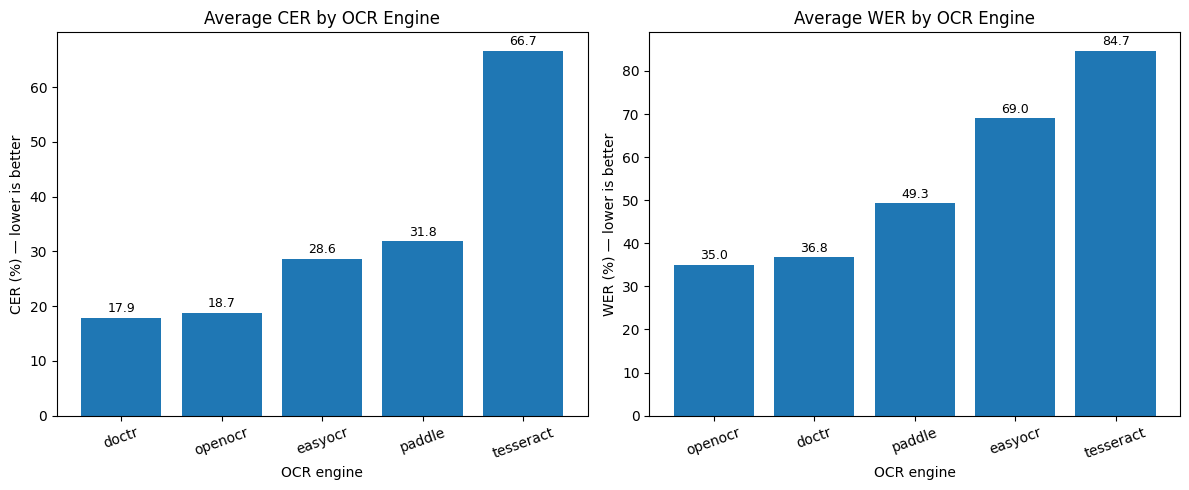

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CER
cer_only = plot_df[plot_df["metric"] == "CER"].sort_values("mean_pct")
ax = axes[0]
bars = ax.bar(cer_only["ocr"], cer_only["mean_pct"])
ax.set_title("Average CER by OCR Engine")
ax.set_ylabel("CER (%) — lower is better")
ax.set_xlabel("OCR engine")
ax.tick_params(axis="x", rotation=20)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=9)

# WER
wer_only = plot_df[plot_df["metric"] == "WER"].sort_values("mean_pct")
ax = axes[1]
bars = ax.bar(wer_only["ocr"], wer_only["mean_pct"])
ax.set_title("Average WER by OCR Engine")
ax.set_ylabel("WER (%) — lower is better")
ax.set_xlabel("OCR engine")
ax.tick_params(axis="x", rotation=20)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

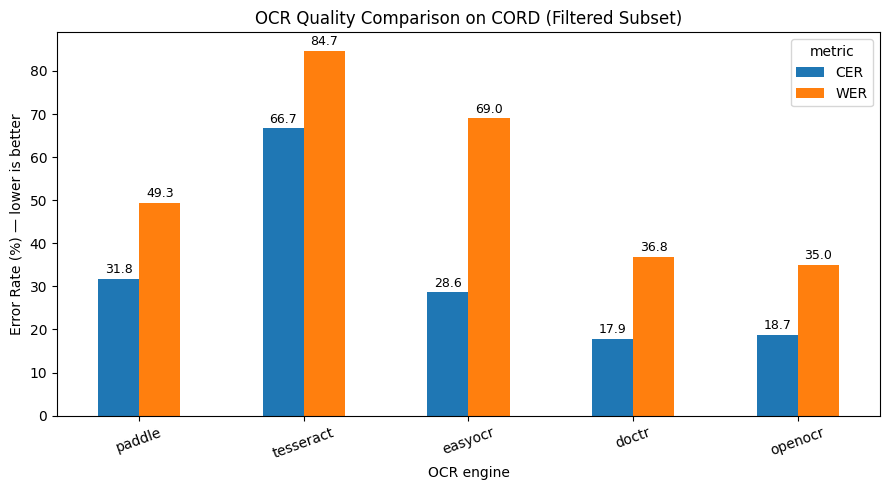

In [49]:
pivot_plot = plot_df.pivot(index="ocr", columns="metric", values="mean_pct")
pivot_plot = pivot_plot.loc[["paddle", "tesseract", "easyocr", "doctr", "openocr"]]

ax = pivot_plot.plot(kind="bar", figsize=(9, 5))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=9)

plt.title("OCR Quality Comparison on CORD (Filtered Subset)")
plt.ylabel("Error Rate (%) — lower is better")
plt.xlabel("OCR engine")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

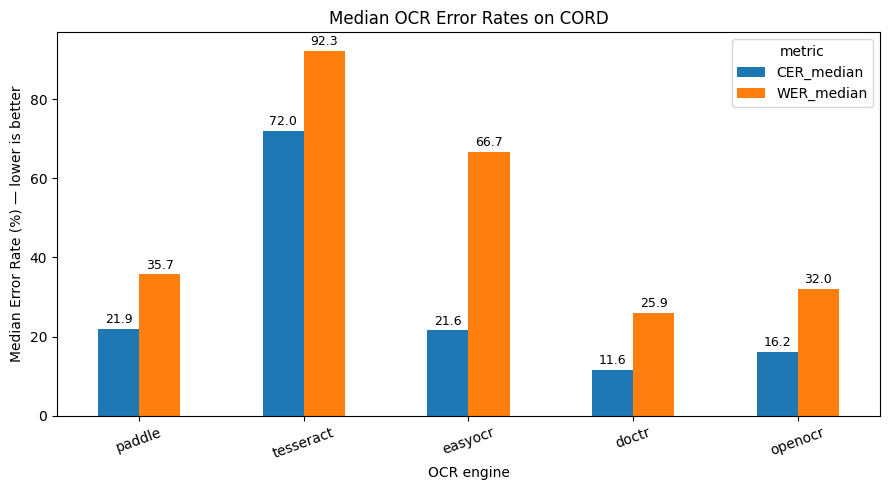

In [50]:
cer_med_plot = cer_light_summary.reset_index()[["ocr", "median"]].copy()
cer_med_plot["metric"] = "CER_median"

wer_med_plot = wer_light_summary.reset_index()[["ocr", "median"]].copy()
wer_med_plot["metric"] = "WER_median"

med_df = pd.concat([cer_med_plot, wer_med_plot], ignore_index=True)
med_df["value_pct"] = med_df["median"] * 100

pivot_med = med_df.pivot(index="ocr", columns="metric", values="value_pct")
pivot_med = pivot_med.loc[["paddle", "tesseract", "easyocr", "doctr", "openocr"]]

ax = pivot_med.plot(kind="bar", figsize=(9, 5))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=9)

plt.title("Median OCR Error Rates on CORD")
plt.ylabel("Median Error Rate (%) — lower is better")
plt.xlabel("OCR engine")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

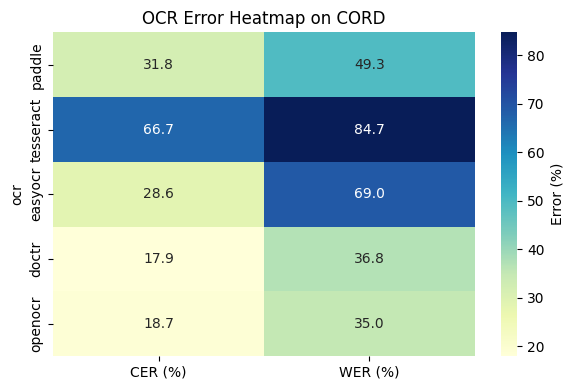

In [51]:
import seaborn as sns

heat_df = pd.DataFrame({
    "CER (%)": cer_light_summary["mean"] * 100,
    "WER (%)": wer_light_summary["mean"] * 100,
})

heat_df = heat_df.loc[["paddle", "tesseract", "easyocr", "doctr", "openocr"]]

plt.figure(figsize=(6, 4))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Error (%)"})
plt.title("OCR Error Heatmap on CORD")
plt.tight_layout()
plt.show()

### REGEX CORD

In [52]:
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
from rapidfuzz import fuzz
from rapidfuzz.distance import Levenshtein
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

REGEX_FILES = {
    "paddle_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/paddle_regex_cord_test_filtered.json"),
    "tesseract_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/tesseract_regex_cord_test_filtered.json"),
    "easyocr_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/easyocr_regex_cord_test_filtered.json"),
    "doctr_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/doctr_regex_cord_test_filtered.json"),
    "openocr_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/openocr_regex_cord_test_filtered.json"),
}

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

regex_data = {name: load_json(path) for name, path in REGEX_FILES.items()}
{k: len(v) for k, v in regex_data.items()}

{'paddle_regex': 83,
 'tesseract_regex': 83,
 'easyocr_regex': 83,
 'doctr_regex': 83,
 'openocr_regex': 83}

In [54]:
ds = load_dataset("naver-clova-ix/cord-v2", split="test")

FIELDS = ["item_name", "item_price", "sub_total", "tax", "total"]

def image_id(name):
    return Path(str(name)).stem

def first_menu_entry(menu):
    if isinstance(menu, list):
        return menu[0] if len(menu) > 0 and isinstance(menu[0], dict) else {}
    if isinstance(menu, dict):
        return menu
    return {}

def gt_from_sample(sample):
    gt = json.loads(sample["ground_truth"])
    gp = gt.get("gt_parse", {})

    menu = first_menu_entry(gp.get("menu", {}))
    subtotal = gp.get("sub_total", {})
    total = gp.get("total", {})

    if not isinstance(subtotal, dict):
        subtotal = {}
    if not isinstance(total, dict):
        total = {}

    return {
        "source_image": f'{gt["meta"]["image_id"]}.png',
        "item_name": menu.get("nm"),
        "item_price": menu.get("price"),
        "sub_total": subtotal.get("subtotal_price"),
        "tax": subtotal.get("tax_price"),
        "total": total.get("total_price"),
    }

gt_all = [gt_from_sample(s) for s in ds]
gt_map = {image_id(x["source_image"]): x for x in gt_all}

# common filtered ids from regex files
id_sets = []
for records in regex_data.values():
    ids = {image_id(r["source_image"]) for r in records}
    id_sets.append(ids)

common_ids = sorted(set.intersection(*id_sets), key=int)

print("Common filtered IDs:", len(common_ids))
print(common_ids[:10])
print(gt_map[common_ids[0]])

Common filtered IDs: 83
['0', '1', '2', '3', '4', '6', '7', '8', '9', '10']
{'source_image': '0.png', 'item_name': '-TICKET CP', 'item_price': '60.000', 'sub_total': '60.000', 'tax': '5.455', 'total': '60.000'}


In [55]:
sample0 = json.loads(ds[0]["ground_truth"])
print(type(sample0["gt_parse"]["menu"]))
print(sample0["gt_parse"]["menu"])

<class 'dict'>
{'nm': '-TICKET CP', 'num': '901016', 'cnt': '2', 'price': '60.000', 'itemsubtotal': '60.000'}


In [56]:
def norm_text(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    x = x.replace(",", ".")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def exact_match(pred, gold):
    return 1 if norm_text(pred) == norm_text(gold) and norm_text(gold) != "" else 0

def fuzzy_score(pred, gold):
    p, g = norm_text(pred), norm_text(gold)
    if not g:
        return 0.0
    return fuzz.ratio(p, g) / 100.0

def lev_similarity(pred, gold):
    p, g = norm_text(pred), norm_text(gold)
    if not g:
        return 0.0
    return 1 - Levenshtein.distance(p, g) / max(len(g), 1)

def field_confusion(pred, gold):
    p, g = norm_text(pred), norm_text(gold)
    if g and p == g:
        return 1, 0, 0
    if g and p and p != g:
        return 0, 1, 1
    if g and not p:
        return 0, 0, 1
    if not g and p:
        return 0, 1, 0
    return 0, 0, 0

In [57]:
def evaluate_method(records, method_name):
    rec_map = {image_id(r["source_image"]): r for r in records}
    rows = []

    for field in FIELDS:
        exacts, fuzzies, levs = [], [], []
        tp = fp = fn = 0

        for sid in common_ids:
            gold = gt_map[sid].get(field)
            pred = rec_map[sid].get(field)

            exacts.append(exact_match(pred, gold))
            fuzzies.append(fuzzy_score(pred, gold))
            levs.append(lev_similarity(pred, gold))

            tpi, fpi, fni = field_confusion(pred, gold)
            tp += tpi
            fp += fpi
            fn += fni

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows.append({
            "method": method_name,
            "field": field,
            "exact_match": np.mean(exacts),
            "fuzzy_score": np.mean(fuzzies),
            "lev_similarity": np.mean(levs),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
        })

    return pd.DataFrame(rows)

In [58]:
regex_eval = pd.concat(
    [evaluate_method(records, name) for name, records in regex_data.items()],
    ignore_index=True
)

regex_eval

,method,field,exact_match,fuzzy_score,lev_similarity,precision,recall,f1_score
0,paddle_regex,item_name,0.216867,0.499542,0.406372,0.216867,0.216867,0.216867
1,paddle_regex,item_price,0.072289,0.500592,0.434715,0.072289,0.073171,0.072727
2,paddle_regex,sub_total,0.397590,0.417072,0.413865,0.846154,0.647059,0.733333
3,paddle_regex,tax,0.060241,0.097687,0.085055,0.277778,0.156250,0.200000
4,paddle_regex,total,0.445783,0.597218,0.574947,0.569231,0.474359,0.517483
5,tesseract_regex,item_name,0.072289,0.332462,0.154523,0.100000,0.072289,0.083916
6,tesseract_regex,item_price,0.048193,0.320352,0.270458,0.072727,0.048780,0.058394
7,tesseract_regex,sub_total,0.084337,0.124861,0.114515,0.411765,0.137255,0.205882
8,tesseract_regex,tax,0.024096,0.038286,0.035255,0.285714,0.062500,0.102564
9,tesseract_regex,total,0.144578,0.229309,0.212909,0.413793,0.153846,0.224299


In [59]:
regex_summary = (
    regex_eval.groupby("method")[["exact_match", "fuzzy_score", "lev_similarity", "f1_score"]]
    .mean()
    .sort_values("f1_score", ascending=False)
)

(regex_summary * 100).round(1)

,exact_match,fuzzy_score,lev_similarity,f1_score
method,,,,
doctr_regex,29.6,50.1,46.0,41.3
openocr_regex,26.0,48.2,44.2,37.9
paddle_regex,23.9,42.2,38.3,34.8
easyocr_regex,16.4,38.1,33.1,23.5
tesseract_regex,7.5,20.9,15.8,13.5


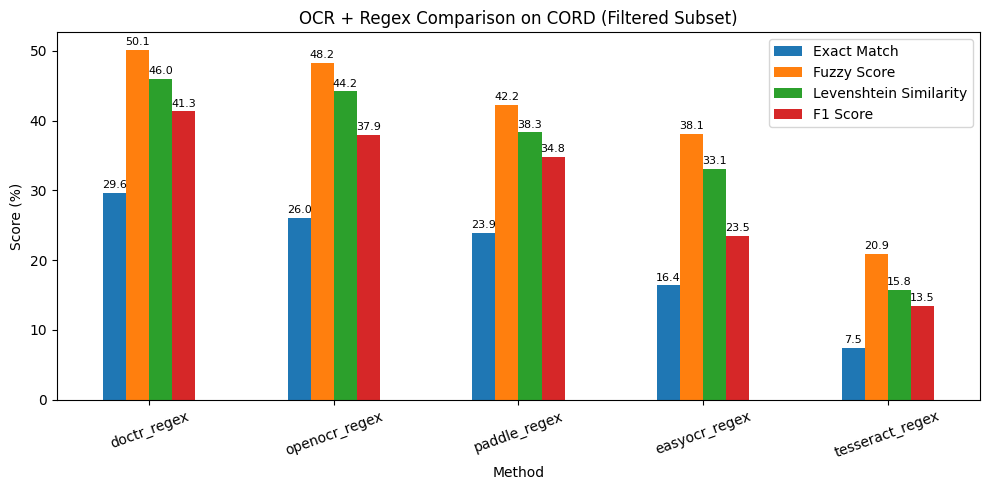

In [60]:
plot_summary = (regex_summary * 100).rename(columns={
    "exact_match": "Exact Match",
    "fuzzy_score": "Fuzzy Score",
    "lev_similarity": "Levenshtein Similarity",
    "f1_score": "F1 Score",
})

ax = plot_summary.plot(kind="bar", figsize=(10, 5))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)

plt.title("OCR + Regex Comparison on CORD (Filtered Subset)")
plt.ylabel("Score (%)")
plt.xlabel("Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

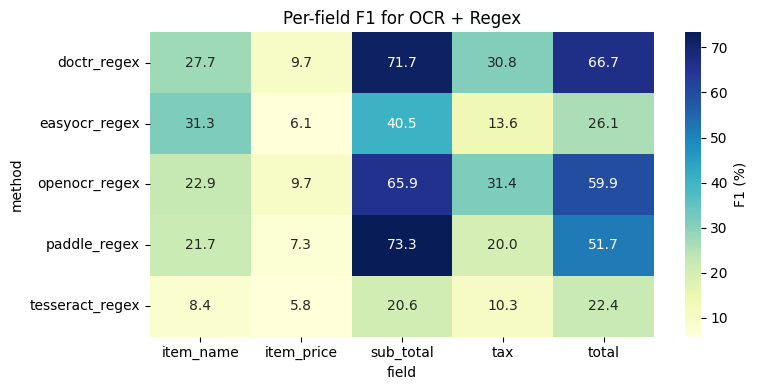

In [61]:
pivot_f1 = regex_eval.pivot(index="method", columns="field", values="f1_score") * 100

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_f1, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "F1 (%)"})
plt.title("Per-field F1 for OCR + Regex")
plt.tight_layout()
plt.show()

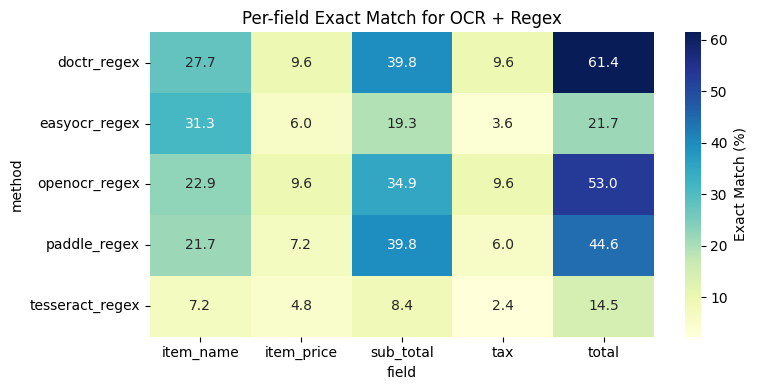

In [62]:
pivot_exact = regex_eval.pivot(index="method", columns="field", values="exact_match") * 100

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_exact, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Exact Match (%)"})
plt.title("Per-field Exact Match for OCR + Regex")
plt.tight_layout()
plt.show()

### ocr+llm


In [65]:
LLM_FILES = {
    "doctr_llm": Path("/root/lorex-ocr-llm-experiments/results/cord_llm/doctr_llm_cord_test_filtered.json"),
    "openocr_llm": Path("/root/lorex-ocr-llm-experiments/results/cord_llm/openocr_llm_cord_test_filtered.json"),
    "paddle_llm": Path("/root/lorex-ocr-llm-experiments/results/cord_llm/paddle_llm_cord_test_filtered.json"),
}

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

llm_data = {name: load_json(path) for name, path in LLM_FILES.items()}
{k: len(v) for k, v in llm_data.items()}

{'doctr_llm': 83, 'openocr_llm': 83, 'paddle_llm': 83}

In [66]:
ds = load_dataset("naver-clova-ix/cord-v2", split="test")

FIELDS = ["item_name", "item_price", "sub_total", "tax", "total"]

def image_id(name):
    return Path(str(name)).stem

def first_menu_entry(menu):
    if isinstance(menu, list):
        return menu[0] if len(menu) > 0 and isinstance(menu[0], dict) else {}
    if isinstance(menu, dict):
        return menu
    return {}

def gt_from_sample(sample):
    gt = json.loads(sample["ground_truth"])
    gp = gt.get("gt_parse", {})

    menu = first_menu_entry(gp.get("menu", {}))
    subtotal = gp.get("sub_total", {})
    total = gp.get("total", {})

    if not isinstance(subtotal, dict):
        subtotal = {}
    if not isinstance(total, dict):
        total = {}

    return {
        "source_image": f'{gt["meta"]["image_id"]}.png',
        "item_name": menu.get("nm"),
        "item_price": menu.get("price"),
        "sub_total": subtotal.get("subtotal_price"),
        "tax": subtotal.get("tax_price"),
        "total": total.get("total_price"),
    }

gt_all = [gt_from_sample(s) for s in ds]
gt_map = {image_id(x["source_image"]): x for x in gt_all}

print(gt_map["0"])

{'source_image': '0.png', 'item_name': '-TICKET CP', 'item_price': '60.000', 'sub_total': '60.000', 'tax': '5.455', 'total': '60.000'}


In [67]:
id_sets = []
for records in llm_data.values():
    ids = {image_id(r["source_image"]) for r in records}
    id_sets.append(ids)

common_ids_llm = sorted(set.intersection(*id_sets), key=int)

print("Common IDs:", len(common_ids_llm))
print(common_ids_llm[:10])

Common IDs: 83
['0', '1', '2', '3', '4', '6', '7', '8', '9', '10']


In [68]:
def norm_text(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    x = x.replace(",", ".")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def exact_match(pred, gold):
    return 1 if norm_text(pred) == norm_text(gold) and norm_text(gold) != "" else 0

def fuzzy_score(pred, gold):
    p, g = norm_text(pred), norm_text(gold)
    if not g:
        return 0.0
    return fuzz.ratio(p, g) / 100.0

def lev_similarity(pred, gold):
    p, g = norm_text(pred), norm_text(gold)
    if not g:
        return 0.0
    return 1 - Levenshtein.distance(p, g) / max(len(g), 1)

def field_confusion(pred, gold):
    p, g = norm_text(pred), norm_text(gold)
    if g and p == g:
        return 1, 0, 0
    if g and p and p != g:
        return 0, 1, 1
    if g and not p:
        return 0, 0, 1
    if not g and p:
        return 0, 1, 0
    return 0, 0, 0

In [69]:
def evaluate_method(records, method_name, common_ids):
    rec_map = {image_id(r["source_image"]): r for r in records}
    rows = []

    for field in FIELDS:
        exacts, fuzzies, levs = [], [], []
        tp = fp = fn = 0

        for sid in common_ids:
            gold = gt_map[sid].get(field)
            pred = rec_map[sid].get(field)

            exacts.append(exact_match(pred, gold))
            fuzzies.append(fuzzy_score(pred, gold))
            levs.append(lev_similarity(pred, gold))

            tpi, fpi, fni = field_confusion(pred, gold)
            tp += tpi
            fp += fpi
            fn += fni

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows.append({
            "method": method_name,
            "field": field,
            "exact_match": np.mean(exacts),
            "fuzzy_score": np.mean(fuzzies),
            "lev_similarity": np.mean(levs),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
        })

    return pd.DataFrame(rows)

In [70]:
llm_eval = pd.concat(
    [evaluate_method(records, name, common_ids_llm) for name, records in llm_data.items()],
    ignore_index=True
)

llm_eval

,method,field,exact_match,fuzzy_score,lev_similarity,precision,recall,f1_score
0,doctr_llm,item_name,0.518072,0.854616,0.759462,0.530864,0.518072,0.524390
1,doctr_llm,item_price,0.759036,0.892012,0.862784,0.777778,0.768293,0.773006
2,doctr_llm,sub_total,0.373494,0.402945,0.402945,0.911765,0.607843,0.729412
3,doctr_llm,tax,0.265060,0.291208,0.225186,0.758621,0.687500,0.721311
4,doctr_llm,total,0.795181,0.857772,0.842704,0.825000,0.846154,0.835443
5,openocr_llm,item_name,0.409639,0.757128,0.640710,0.419753,0.409639,0.414634
6,openocr_llm,item_price,0.602410,0.803408,0.774737,0.625000,0.609756,0.617284
7,openocr_llm,sub_total,0.325301,0.362467,0.356282,0.843750,0.529412,0.650602
8,openocr_llm,tax,0.228916,0.278438,0.197476,0.655172,0.593750,0.622951
9,openocr_llm,total,0.722892,0.856253,0.845114,0.769231,0.769231,0.769231


In [72]:
llm_summary = (
    llm_eval.groupby("method")[["exact_match", "fuzzy_score", "lev_similarity", "f1_score"]]
    .mean()
    .sort_values("f1_score", ascending=False)
)

(llm_summary * 100).round(1)

,exact_match,fuzzy_score,lev_similarity,f1_score
method,,,,
doctr_llm,54.2,66.0,61.9,71.7
paddle_llm,46.0,59.1,54.6,62.0
openocr_llm,45.8,61.2,56.3,61.5


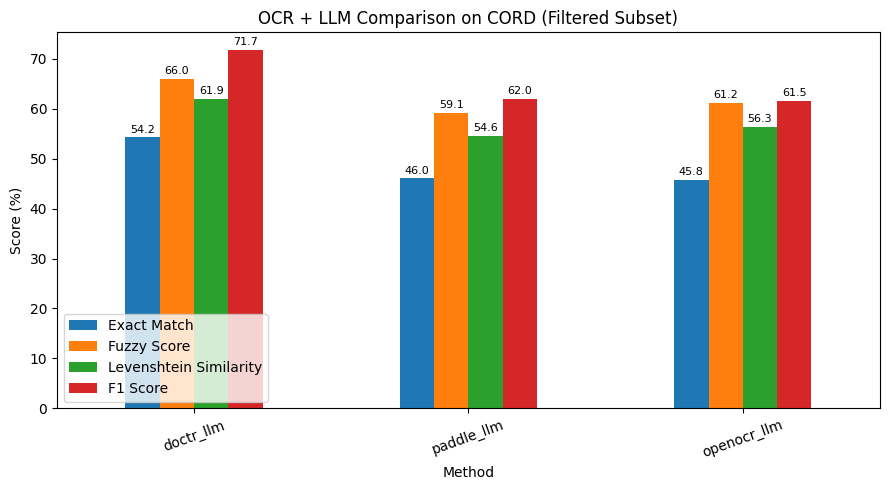

In [73]:
plot_summary = (llm_summary * 100).rename(columns={
    "exact_match": "Exact Match",
    "fuzzy_score": "Fuzzy Score",
    "lev_similarity": "Levenshtein Similarity",
    "f1_score": "F1 Score",
})

ax = plot_summary.plot(kind="bar", figsize=(9, 5))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)

plt.title("OCR + LLM Comparison on CORD (Filtered Subset)")
plt.ylabel("Score (%)")
plt.xlabel("Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

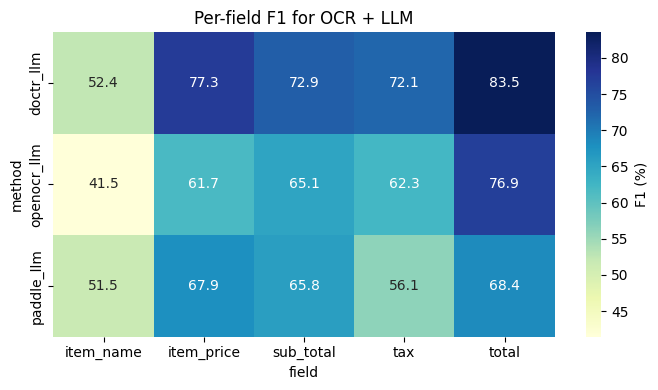

In [74]:
pivot_f1_llm = llm_eval.pivot(index="method", columns="field", values="f1_score") * 100

plt.figure(figsize=(7, 4))
sns.heatmap(pivot_f1_llm, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "F1 (%)"})
plt.title("Per-field F1 for OCR + LLM")
plt.tight_layout()
plt.show()

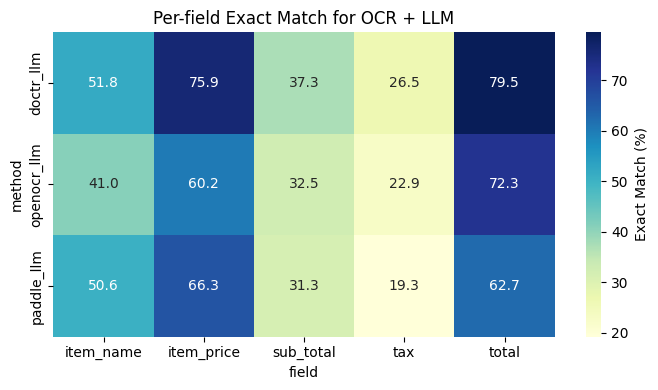

In [75]:
pivot_exact_llm = llm_eval.pivot(index="method", columns="field", values="exact_match") * 100

plt.figure(figsize=(7, 4))
sns.heatmap(pivot_exact_llm, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Exact Match (%)"})
plt.title("Per-field Exact Match for OCR + LLM")
plt.tight_layout()
plt.show()

### Combined

In [89]:
ALL_FILES = {
    # OCR + REGEX (5)
    "doctr_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/doctr_regex_cord_test_filtered.json"),
    "openocr_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/openocr_regex_cord_test_filtered.json"),
    "paddle_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/paddle_regex_cord_test_filtered.json"),
    "easyocr_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/easyocr_regex_cord_test_filtered.json"),
    "tesseract_regex": Path("/root/lorex-ocr-llm-experiments/results/cord_regex/tesseract_regex_cord_test_filtered.json"),

    # OCR + LLM (3)
    "doctr_llm": Path("/root/lorex-ocr-llm-experiments/results/cord_llm/doctr_llm_cord_test_filtered.json"),
    "openocr_llm": Path("/root/lorex-ocr-llm-experiments/results/cord_llm/openocr_llm_cord_test_filtered.json"),
    "paddle_llm": Path("/root/lorex-ocr-llm-experiments/results/cord_llm/paddle_llm_cord_test_filtered.json"),

    # VLM (1)
    "qwen_vlm": Path("/root/lorex-ocr-llm-experiments/results/cord_vlm/qwen_vlm_7b_cord_test_filtered.json"),
}

all_data = {name: load_json(path) for name, path in ALL_FILES.items()}
{k: len(v) for k, v in all_data.items()}

{'doctr_regex': 83,
 'openocr_regex': 83,
 'paddle_regex': 83,
 'easyocr_regex': 83,
 'tesseract_regex': 83,
 'doctr_llm': 83,
 'openocr_llm': 83,
 'paddle_llm': 83,
 'qwen_vlm': 83}

In [90]:
id_sets = []
for records in all_data.values():
    ids = {image_id(r["source_image"]) for r in records}
    id_sets.append(ids)

common_ids_all = sorted(set.intersection(*id_sets), key=int)

print("Final common IDs:", len(common_ids_all))

Final common IDs: 83


In [91]:
all_eval = pd.concat(
    [evaluate_method(records, name, common_ids_all) for name, records in all_data.items()],
    ignore_index=True
)

In [ ]:
final_summary = (
    all_eval.groupby("method")[["exact_match", "fuzzy_score", "lev_similarity", "f1_score"]]
    .mean()
    .sort_values("f1_score", ascending=False)
)

(final_summary * 100).round(1)

,exact_match,fuzzy_score,lev_similarity,f1_score
method,,,,
qwen_vlm,71.1,76.0,75.2,90.9
doctr_llm,54.2,66.0,61.9,71.7
paddle_llm,46.0,59.1,54.6,62.0
openocr_llm,45.8,61.2,56.3,61.5
doctr_regex,29.6,50.1,46.0,41.3
openocr_regex,26.0,48.2,44.2,37.9
paddle_regex,23.9,42.2,38.3,34.8
easyocr_regex,16.4,38.1,33.1,23.5
tesseract_regex,7.5,20.9,15.8,13.5


In [93]:
print(sorted(all_data.keys()))

['doctr_llm', 'doctr_regex', 'easyocr_regex', 'openocr_llm', 'openocr_regex', 'paddle_llm', 'paddle_regex', 'qwen_vlm', 'tesseract_regex']


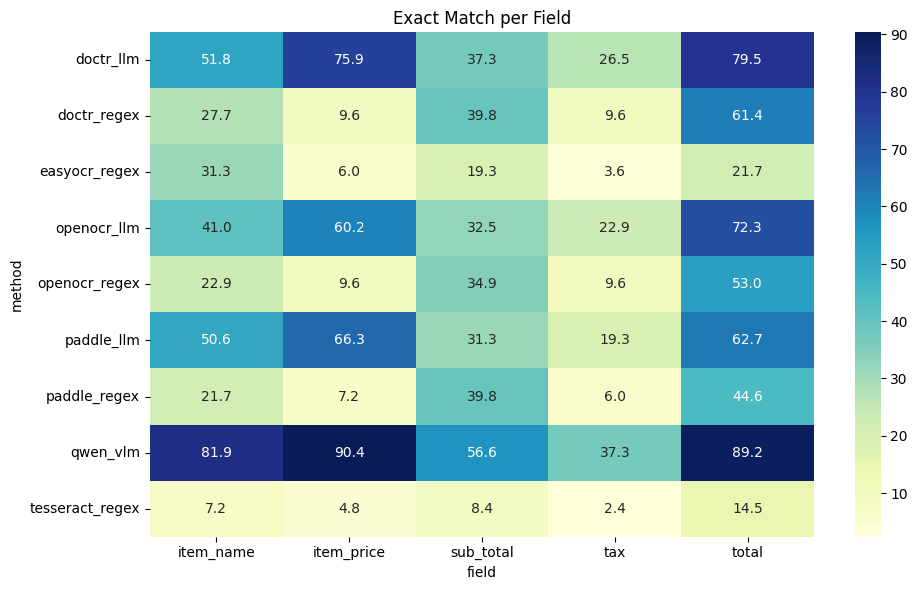

In [95]:
pivot_exact = all_eval.pivot(index="method", columns="field", values="exact_match") * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_exact, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Exact Match per Field")
plt.tight_layout()
plt.show()

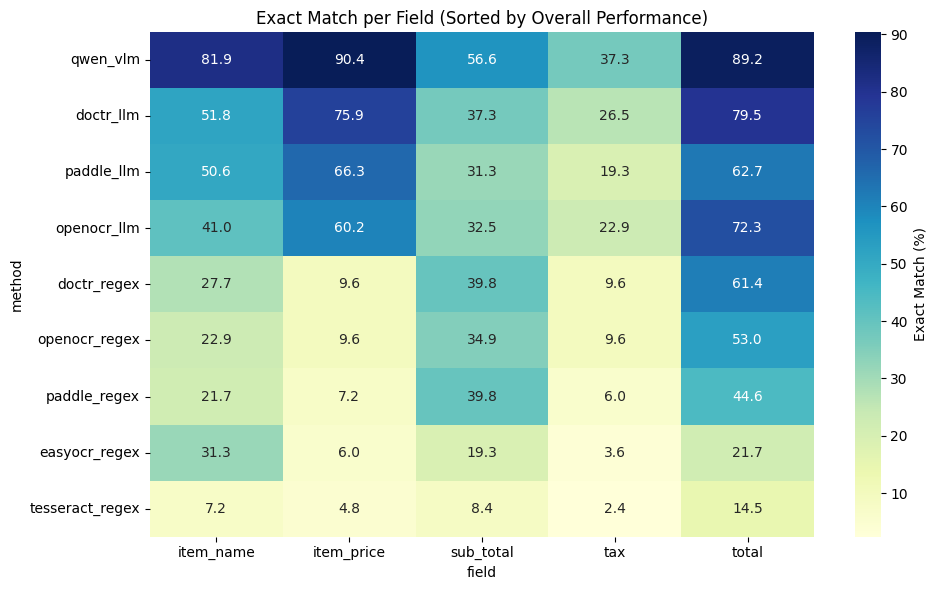

In [96]:
# Sort methods by overall F1 (best → worst)
sorted_methods = final_summary.sort_values("f1_score", ascending=False).index

pivot_sorted = pivot_exact.loc[sorted_methods]

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_sorted,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Exact Match (%)"}
)

plt.title("Exact Match per Field (Sorted by Overall Performance)")
plt.tight_layout()
plt.show()

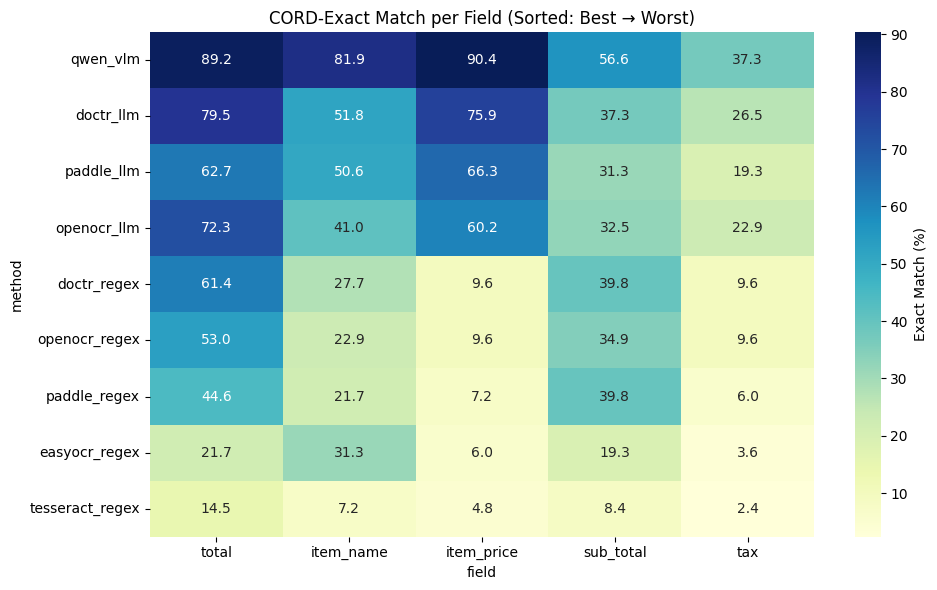

In [107]:
row_order = pivot_exact.mean(axis=1).sort_values(ascending=False).index
col_order = pivot_exact.mean(axis=0).sort_values(ascending=False).index

pivot_sorted = pivot_exact.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_sorted,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Exact Match (%)"}
)

plt.title("CORD-Exact Match per Field (Sorted: Best → Worst)")
plt.tight_layout()
plt.show()

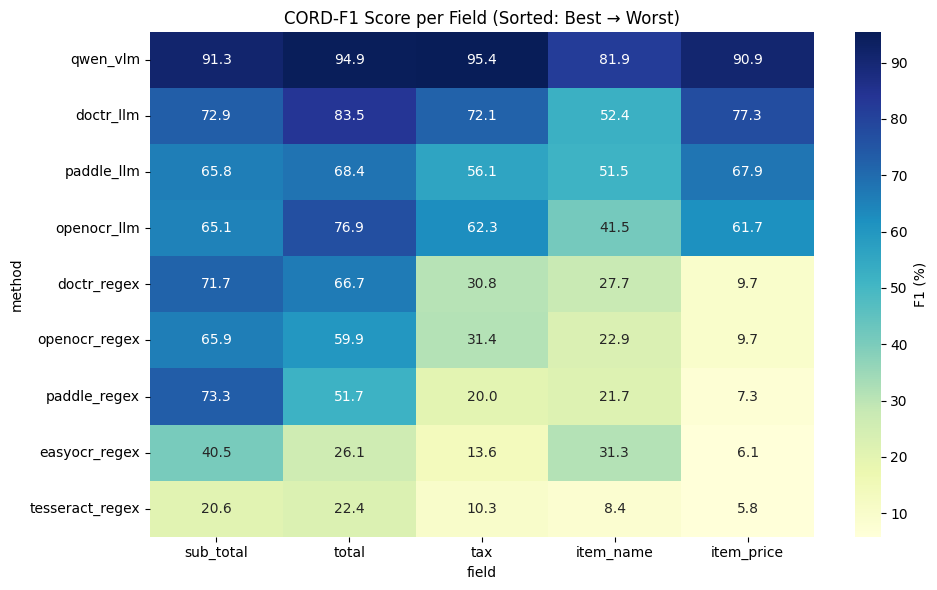

In [108]:
# Pivot
pivot_f1 = all_eval.pivot(index="method", columns="field", values="f1_score") * 100

# Sort rows (methods) by overall performance
row_order = final_summary.sort_values("f1_score", ascending=False).index

# Sort columns (fields) by average difficulty
col_order = pivot_f1.mean(axis=0).sort_values(ascending=False).index

pivot_f1_sorted = pivot_f1.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_f1_sorted,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "F1 (%)"}
)

plt.title("CORD-F1 Score per Field (Sorted: Best → Worst)")
plt.tight_layout()
plt.show()

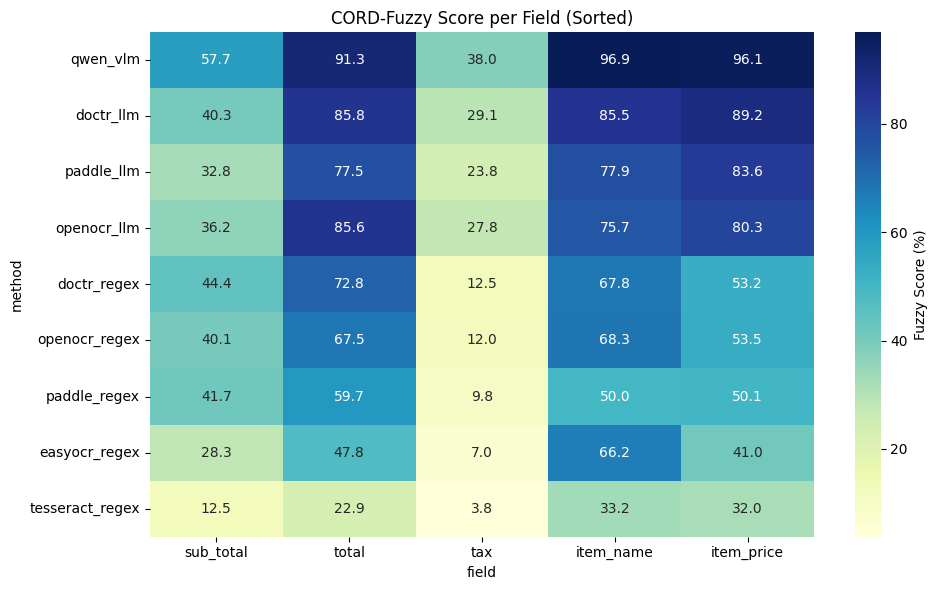

In [109]:
pivot_fuzzy = all_eval.pivot(index="method", columns="field", values="fuzzy_score") * 100

pivot_fuzzy_sorted = pivot_fuzzy.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_fuzzy_sorted,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Fuzzy Score (%)"}
)

plt.title("CORD-Fuzzy Score per Field (Sorted)")
plt.tight_layout()
plt.show()

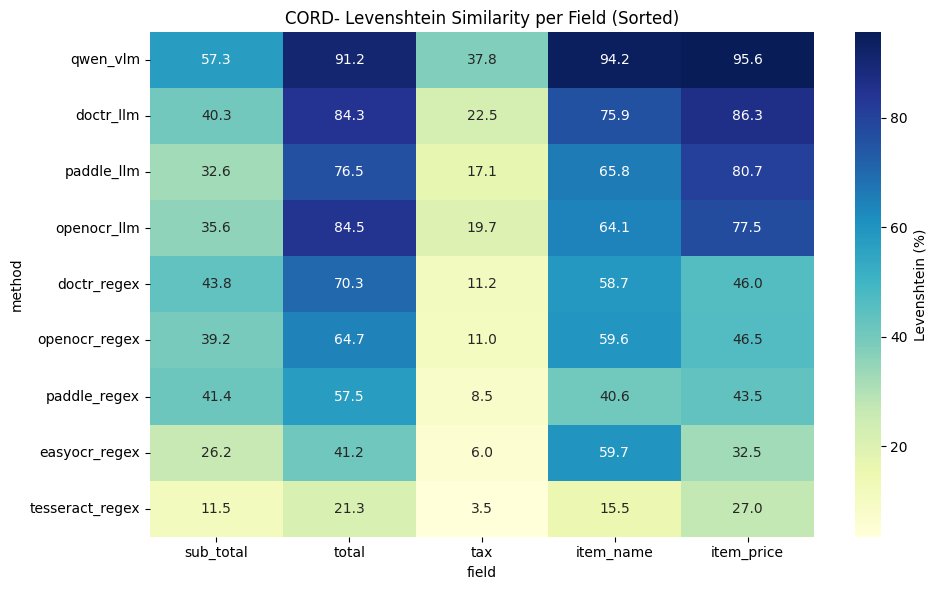

In [110]:
pivot_lev = all_eval.pivot(index="method", columns="field", values="lev_similarity") * 100

pivot_lev_sorted = pivot_lev.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_lev_sorted,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Levenshtein (%)"}
)

plt.title("CORD- Levenshtein Similarity per Field (Sorted)")
plt.tight_layout()
plt.show()

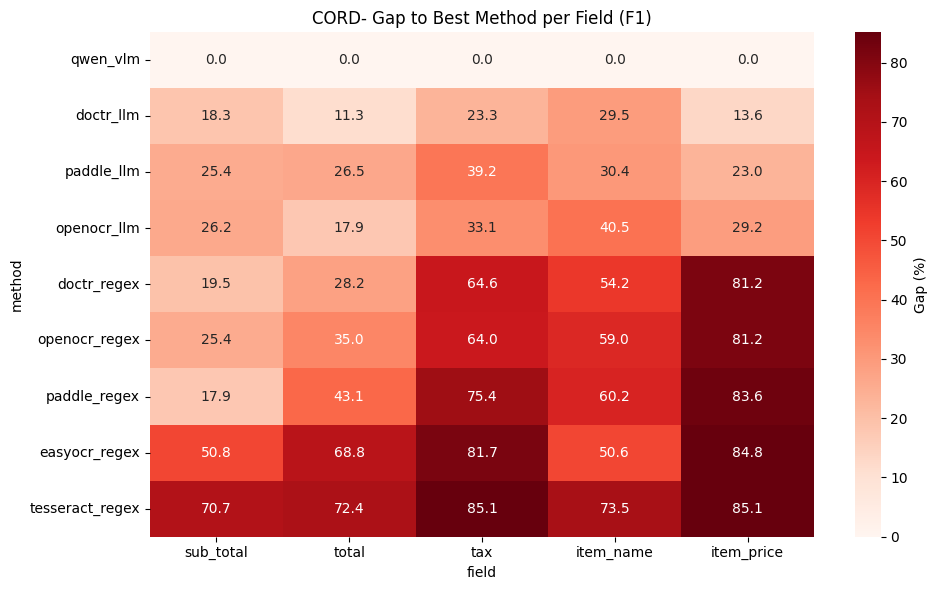

In [111]:
best_per_field = pivot_f1.max(axis=0)

gap = best_per_field - pivot_f1

gap_sorted = gap.loc[row_order, col_order]

plt.figure(figsize=(10, 6))
sns.heatmap(
    gap_sorted,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Gap (%)"}
)

plt.title("CORD- Gap to Best Method per Field (F1)")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

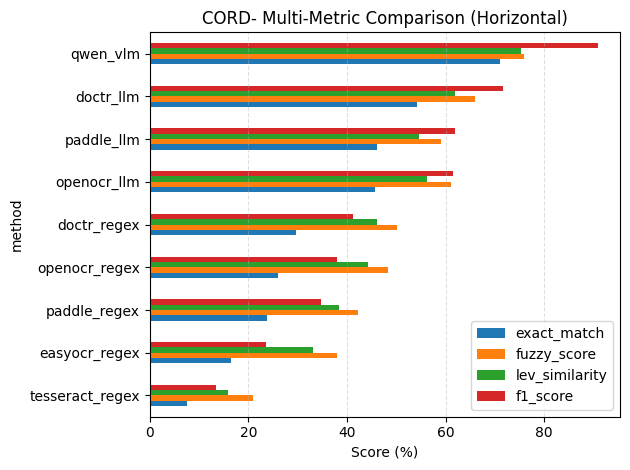

In [113]:
plot_df = (final_summary * 100).sort_values("f1_score")

plt.figure(figsize=(10, 6))

plot_df[["exact_match", "fuzzy_score", "lev_similarity", "f1_score"]].plot(
    kind="barh"
)

plt.xlabel("Score (%)")
plt.title("CORD- Multi-Metric Comparison (Horizontal)")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()